In [5]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [7]:
import numpy as np
import networkx as nx
from sksparse.cholmod import cholesky as sparse_cholesky

In [10]:
edges, n_vertices, weights = load_graph(r"../../data/raw/oregon1_010526.txt")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/oregon1_010526.txt
  Vertices : 11174
  Edges    : 23409
  Weighted : no

n_vertices=11174, edges=23409


In [13]:
check_connectivity(edges, n_vertices)

Components: 1
  -> Graph is fully connected, safe to proceed



1

In [16]:
# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

# 4. Phase 2 — sparse from the start, given graph size
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 11174 x 11174
  Degree range: [1, 2389]
  Non-zeros in L: 57992

✓ lambda_min = 0.032899
  (eigenvalues found: [0.         0.03289937])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


In [19]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [22]:
gamma_in, gamma_out, diameter = find_diameter_endpoints(G_nx, n_sample=5, k_hop=4)

In [25]:
diameter

10

In [96]:
import time

t0 = time.time()
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                    gamma_in, gamma_out, N=1000, debug=False)
elapsed = time.time() - t0

print(f"Time: {elapsed:.2f}s")
print(f"Mean Q: {Q_samples.mean():.6f}")
print(f"Std Q: {Q_samples.std():.6f}")

Monte Carlo: 100%|██████████| 1000/1000 [04:10<00:00,  4.00sample/s, mean Q=17.5302]


✓ Done — 1000 samples
  Mean Q : 17.530224
  Std Q  : 3.593987
Time: 250.57s
Mean Q: 17.530224
Std Q: 3.593987


In [108]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")

ax.hist(Q_samples, bins=40, color="#4ce0c1", edgecolor="none", alpha=0.9)
ax.axvline(Q_samples.mean(), color="#ff6b5e", linestyle="--", linewidth=2,
           label=f"Mean = {Q_samples.mean():.4f}")

ax.set_xlabel("Q (total flux)", color="white", fontsize=13)
ax.set_ylabel("Frequency", color="white", fontsize=13)
ax.set_title("Distribution of Q", color="white", fontsize=16, pad=12)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.3)
ax.legend(facecolor="none", labelcolor="white", edgecolor="white", framealpha=0.3)

plt.tight_layout()
plt.savefig("q_distribution_dark.png", dpi=200, bbox_inches="tight", transparent=True)
plt.close()
print("saved q_distribution_dark.png")

saved q_distribution_dark.png


In [101]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")

running_mean = np.cumsum(Q_samples) / np.arange(1, len(Q_samples) + 1)

ax.plot(range(1, len(Q_samples) + 1), running_mean, color="#4ce0c1", linewidth=2)
ax.axhline(Q_samples.mean(), color="#ff6b5e", linestyle="--", linewidth=1.5,
           label=f"Final mean = {Q_samples.mean():.4f}")

ax.set_xlabel("Sample count (N)", color="white", fontsize=13)
ax.set_ylabel("Running mean of Q", color="white", fontsize=13)
ax.set_title("Monte Carlo Convergence", color="white", fontsize=16, pad=12)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.3)
ax.legend(facecolor="none", labelcolor="white", edgecolor="white", framealpha=0.3)

plt.tight_layout()
plt.savefig("convergence_dark.png", dpi=200, bbox_inches="tight", transparent=True)
plt.close()
print("saved convergence_dark.png")

saved convergence_dark.png


In [28]:
check_boundary_fraction(gamma_in, gamma_out, n_vertices)

gamma_in: 11, gamma_out: 92, n_vertices: 11174
Boundary fraction: 0.9218%
  -> Likely safe for aggregation (comparable to validated successes).


0.009217827098621801

In [31]:
aggregate_of, n_coarse = build_grouped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)

In [34]:
summary = summarize_aggregation(aggregate_of, n_coarse, gamma_in, gamma_out)

n_coarse: 6285 (6285 aggregates)
Size distribution -- min: 1, max: 10, mean: 1.78
Singletons: 4657 (74.1%)
gamma_in_coarse: 3, gamma_out_coarse: 52
Overlap (must be empty): set()
Interior coarse vertices: 6230 (99.1%)


In [39]:
coarse_edges, coarse_contribs = build_coarse_graph_edges(edges, aggregate_of)
print(f"coarse edges: {len(coarse_edges)}")

coarse edges: 16645


Computing fine layout (this may take a minute for 11,174 vertices)...
Computing coarse layout...


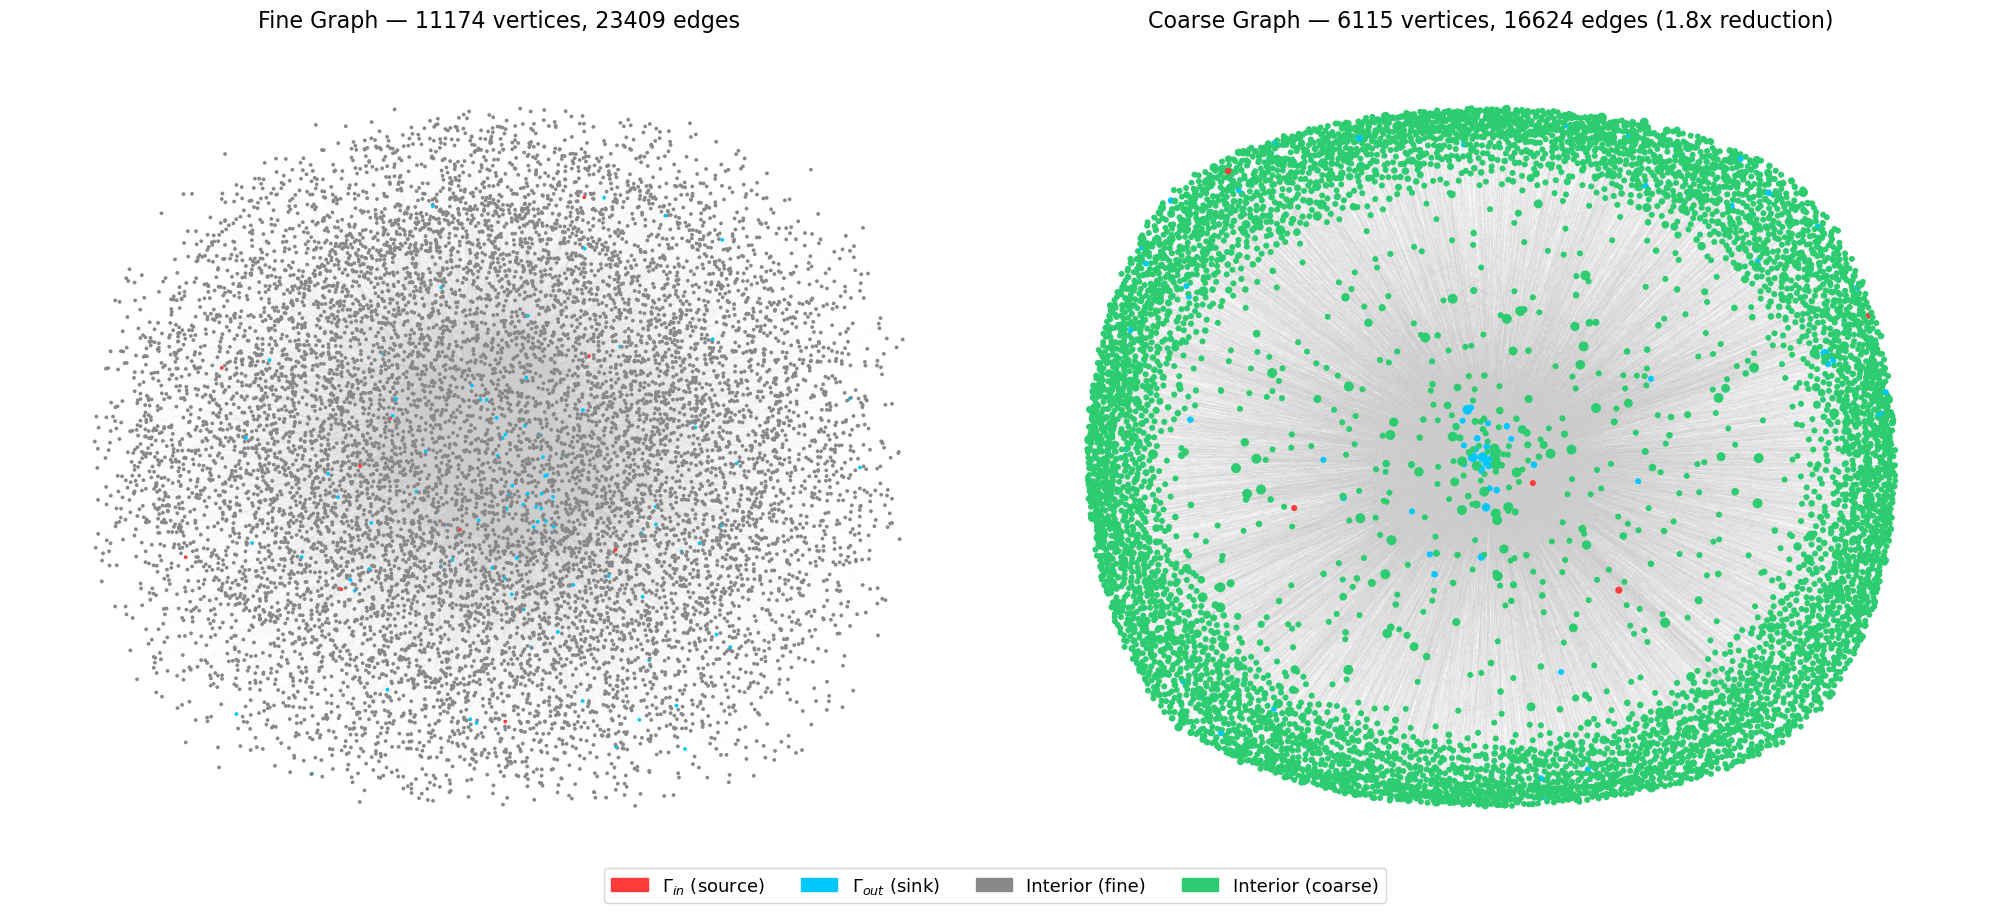

saved oregon_fine_vs_coarse_bright.png


In [90]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- assumes edges, n_vertices, gamma_in, gamma_out, setup already exist
#      from your Oregon Router pipeline (TwoLevelSetup.build(...)) ----

G_nx = nx.Graph()
G_nx.add_nodes_from(range(n_vertices))
G_nx.add_edges_from(edges)

gamma_in_set = set(gamma_in)
gamma_out_set = set(gamma_out)

# ---- Fine graph node colors: bright, high-contrast ----
node_colors_fine = []
for v in range(n_vertices):
    if v in gamma_in_set:
        node_colors_fine.append('#ff3b3b')   # bright red — source
    elif v in gamma_out_set:
        node_colors_fine.append('#00c8ff')   # bright cyan — sink
    else:
        node_colors_fine.append('#888888')   # neutral gray — interior

fig, axes = plt.subplots(1, 2, figsize=(20, 9), facecolor='white')

# ---- Fine graph (large, sparse-looking at this scale) ----
ax = axes[0]
print("Computing fine layout (this may take a minute for 11,174 vertices)...")
pos_fine = nx.spring_layout(G_nx, seed=42, k=0.05, iterations=15)

nx.draw_networkx_edges(G_nx, pos_fine, ax=ax, width=0.1, edge_color='#cccccc', alpha=0.25)
nx.draw_networkx_nodes(G_nx, pos_fine, ax=ax, node_size=3,
                        node_color=node_colors_fine)
ax.set_title(f"Fine Graph — {n_vertices} vertices, {len(edges)} edges", fontsize=16)
ax.axis('off')

# ---- Coarse graph ----
G_coarse = nx.Graph()
G_coarse.add_nodes_from(range(setup.n_coarse))
G_coarse.add_edges_from(setup.coarse_edges)

gamma_in_coarse_set = set(setup.gamma_in_coarse)
gamma_out_coarse_set = set(setup.gamma_out_coarse)

# Use the aggregate_of variable already in your notebook's namespace
# (from when you called build_grouped_aggregation / build_capped_aggregation)
groups = {}
for v, a in aggregate_of.items():
    groups.setdefault(a, []).append(v)

agg_sizes = {a: len(m) for a, m in groups.items()}

node_colors_coarse = []
node_sizes_coarse = []
for a in range(setup.n_coarse):
    size = agg_sizes.get(a, 1)
    node_sizes_coarse.append(8 + size * 3)
    if a in gamma_in_coarse_set:
        node_colors_coarse.append('#ff3b3b')
    elif a in gamma_out_coarse_set:
        node_colors_coarse.append('#00c8ff')
    else:
        node_colors_coarse.append('#2ecc71')   # bright green — interior (coarse)
ax = axes[1]
print("Computing coarse layout...")
pos_coarse = nx.spring_layout(G_coarse, seed=42, k=0.3, iterations=30)

nx.draw_networkx_edges(G_coarse, pos_coarse, ax=ax, width=0.15, edge_color='#cccccc', alpha=0.3)
nx.draw_networkx_nodes(G_coarse, pos_coarse, ax=ax, node_size=node_sizes_coarse,
                        node_color=node_colors_coarse)
ax.set_title(f"Coarse Graph — {setup.n_coarse} vertices, {len(setup.coarse_edges)} edges "
             f"({n_vertices/setup.n_coarse:.1f}x reduction)", fontsize=16)
ax.axis('off')

# ---- Shared legend ----
legend_patches = [
    mpatches.Patch(color='#ff3b3b', label=r'$\Gamma_{in}$ (source)'),
    mpatches.Patch(color='#00c8ff', label=r'$\Gamma_{out}$ (sink)'),
    mpatches.Patch(color='#888888', label='Interior (fine)'),
    mpatches.Patch(color='#2ecc71', label='Interior (coarse)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=13, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("oregon_fine_vs_coarse_bright.png", dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("saved oregon_fine_vs_coarse_bright.png")

In [86]:
print([attr for attr in dir(setup) if not attr.startswith('_')])

['B', 'boundary', 'boundary_coarse', 'build', 'coarse_contribs', 'coarse_edges', 'col_idx', 'col_idx_c', 'edges', 'factor', 'gamma_in', 'gamma_in_coarse', 'gamma_out', 'gamma_out_coarse', 'gamma_out_coarse_set', 'gamma_out_set', 'i_arr', 'i_arr_c', 'interior', 'interior_coarse', 'j_arr', 'j_arr_c', 'lambda_min', 'n_coarse', 'n_vertices', 'p_known', 'p_known_coarse', 'row_idx', 'row_idx_c']


In [88]:
aggregate_of, n_coarse_check = build_grouped_aggregation(G_nx, gamma_in, gamma_out, max_size=10)
print(f"n_coarse_check: {n_coarse_check}, setup.n_coarse: {setup.n_coarse}")

n_coarse_check: 6285, setup.n_coarse: 6115


In [42]:
setup = TwoLevelSetup.build(
    edges, n_vertices, L_sigma, lambda_min,
    gamma_in, gamma_out,
    build_incidence_matrix, sparse_cholesky,
    max_size=10
)

gamma_in: 11, gamma_out: 92, n_vertices: 11174
Boundary fraction: 0.9218%
  -> Likely safe for aggregation (comparable to validated successes).
n_coarse: 6115 (6115 aggregates)
Size distribution -- min: 1, max: 10, mean: 1.83
Singletons: 4483 (73.3%)
gamma_in_coarse: 6, gamma_out_coarse: 74
Overlap (must be empty): set()
Interior coarse vertices: 6035 (98.7%)
coarse edges: 16624 (from 23409 fine edges)


In [46]:
result = run_paired_validation(setup, N=100)

Paired samples: 100%|██████████| 100/100 [00:44<00:00,  2.26sample/s, Q_fine=17.7765, Q_coarse=20.6690]


N = 100 paired samples
Q_fine   : mean=17.776479  var=12.546495
Q_coarse : mean=20.668998  var=17.301356
Q_fine - Q_coarse : mean=-2.892519  var=0.394115
Correlation(Q_fine, Q_coarse): 0.9996
Variance reduction: 31.83x


In [60]:
estimate = two_level_estimate(setup, result, N_coarse_only=600)

Coarse-only samples: 100%|██████████| 600/600 [01:14<00:00,  8.02sample/s, Q_coarse=20.1037]


Coarse-only base estimate (N=600): 20.103735
Correction term mean (paired samples): -2.892519
Two-level estimate of E[Q_fine]: 17.211216
Direct fine-only mean (for comparison): 17.776479


In [68]:
estimate.keys()

dict_keys(['estimate', 'coarse_base_mean', 'correction_mean'])

In [73]:
import numpy as np

N_coarse_only = 600
Q_coarse_only_samples = np.array([
    run_coarse_only_sample(setup, seed=100000+n) for n in range(N_coarse_only)
])

print(f"Coarse-only mean: {Q_coarse_only_samples.mean():.6f}")
print(f"Coarse-only var: {Q_coarse_only_samples.var():.6f}")

N_paired = 100
paired_diff_var = 0.394115  # from your earlier paired run's printed output

se_correction = np.sqrt(paired_diff_var / N_paired)
se_coarse = np.sqrt(Q_coarse_only_samples.var() / N_coarse_only)
combined_se = np.sqrt(se_correction**2 + se_coarse**2)

print(f"\nSE from correction term: {se_correction:.6f}")
print(f"SE from coarse-only term: {se_coarse:.6f}")
print(f"Combined two-level SE: {combined_se:.6f}")
print(f"Target (single-level, N=1000): 0.109200")

Coarse-only mean: 20.103735
Coarse-only var: 18.161016

SE from correction term: 0.062779
SE from coarse-only term: 0.173978
Combined two-level SE: 0.184958
Target (single-level, N=1000): 0.109200


In [77]:
import time
import numpy as np

# ---- Two-level MC: paired samples ----
t0 = time.time()
result = run_paired_validation(setup, N=100)
paired_time = time.time() - t0
print(f"Paired time (N=100): {paired_time:.2f}s")

# ---- Two-level MC: coarse-only samples, matched to reach target SE ----
N_coarse_only = 2300
t0 = time.time()
Q_coarse_only_samples = np.array([
    run_coarse_only_sample(setup, seed=100000+n) for n in range(N_coarse_only)
])
coarse_time = time.time() - t0
print(f"Coarse-only time (N={N_coarse_only}): {coarse_time:.2f}s")

# ---- Combine into the final two-level estimate and its SE ----
coarse_base_mean = Q_coarse_only_samples.mean()
correction_mean = result['diff_samples'].mean()
two_level_estimate_value = coarse_base_mean + correction_mean

se_correction = np.sqrt(result['diff_samples'].var() / 100)
se_coarse = np.sqrt(Q_coarse_only_samples.var() / N_coarse_only)
combined_se = np.sqrt(se_correction**2 + se_coarse**2)

total_two_level_time = paired_time + coarse_time

print(f"\n=== Two-Level MC Summary ===")
print(f"Two-level estimate: {two_level_estimate_value:.6f}")
print(f"Combined SE: {combined_se:.6f}")
print(f"Total time: {total_two_level_time:.2f}s")
print(f"Total fine-graph samples used: {100} (paired only — coarse-only never touches the fine Darcy solve)")

Paired samples: 100%|██████████| 100/100 [00:28<00:00,  3.48sample/s, Q_fine=17.7765, Q_coarse=20.6690]



N = 100 paired samples
Q_fine   : mean=17.776479  var=12.546495
Q_coarse : mean=20.668998  var=17.301356
Q_fine - Q_coarse : mean=-2.892519  var=0.394115
Correlation(Q_fine, Q_coarse): 0.9996
Variance reduction: 31.83x
Paired time (N=100): 28.74s
Coarse-only time (N=2300): 216.04s

=== Two-Level MC Summary ===
Two-level estimate: 17.274355
Combined SE: 0.107225
Total time: 244.78s
Total fine-graph samples used: 100 (paired only — coarse-only never touches the fine Darcy solve)


In [79]:
t0 = time.time()
Q_samples_single = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                                            gamma_in, gamma_out, N=1000, debug=False)
single_level_time = time.time() - t0
print(f"Single-level time (N=1000): {single_level_time:.2f}s")

Monte Carlo: 100%|██████████| 1000/1000 [06:33<00:00,  2.54sample/s, mean Q=17.5436]


✓ Done — 1000 samples
  Mean Q : 17.543649
  Std Q  : 3.466116
Single-level time (N=1000): 393.93s
